# Stage 6 — Model Development

## US Accident Severity Prediction

This notebook develops and compares multiple baseline machine learning models for predicting accident severity.

The objectives are to:

- Train at least four suitable machine learning algorithms.
- Use an appropriate validation strategy.
- Evaluate models using multiple performance metrics.
- Pay particular attention to performance across the imbalanced severity classes.
- Compare model performance systematically.
- Record important observations for the later model optimization stage.

## Modelling Objective

The objective is to predict accident severity as a multiclass classification problem.

The target variable is `Severity`, with four classes:

- Severity 1
- Severity 2
- Severity 3
- Severity 4

The final preprocessed dataset contains numerical predictor features with missing and infinite values already handled during preprocessing.

Because the target variable is highly imbalanced, model performance will not be evaluated using accuracy alone. Macro-averaged metrics and per-class performance will also be considered.

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_SEED = 42

In [2]:
TRAIN_PATH = "../data/train_final.csv"
TEST_PATH = "../data/test_final.csv"

print("Training file:", TRAIN_PATH)
print("Testing file:", TEST_PATH)

Training file: ../data/train_final.csv
Testing file: ../data/test_final.csv


In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (799673, 139)
Testing shape: (199919, 139)


### Separate Predictors and Target

The target variable `Severity` is separated from the predictor variables.

`X` represents the input features and `y` represents the accident severity class to be predicted.

In [4]:
TARGET = "Severity"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (799673, 138)
y_train: (799673,)
X_test: (199919, 138)
y_test: (199919,)


### Verify Data Quality

Before training the models, the final datasets are checked for missing values and infinite values.

The number of predictor features is also verified to ensure that the training and testing datasets have the same feature structure.

In [5]:
print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test:", X_test.isna().sum().sum())

print("Infinite values in X_train:", np.isinf(X_train.select_dtypes(include=np.number)).sum().sum())
print("Infinite values in X_test:", np.isinf(X_test.select_dtypes(include=np.number)).sum().sum())

print("Number of training features:", X_train.shape[1])
print("Number of test features:", X_test.shape[1])

Missing values in X_train: 0
Missing values in X_test: 0
Infinite values in X_train: 0
Infinite values in X_test: 0
Number of training features: 138
Number of test features: 138


## Target Class Distribution

The distribution of the `Severity` target variable is examined in the training dataset.

This is important because the earlier exploratory analysis identified substantial class imbalance, with Severity 2 forming the majority class.

In [6]:
train_target_distribution = (
    y_train.value_counts()
    .sort_index()
    .to_frame("Count")
)

train_target_distribution["Percentage"] = (
    train_target_distribution["Count"]
    / len(y_train)
    * 100
)

train_target_distribution

,Count,Percentage
Severity,,
1,6890,0.861602
2,636908,79.646055
3,134945,16.875023
4,20930,2.617320


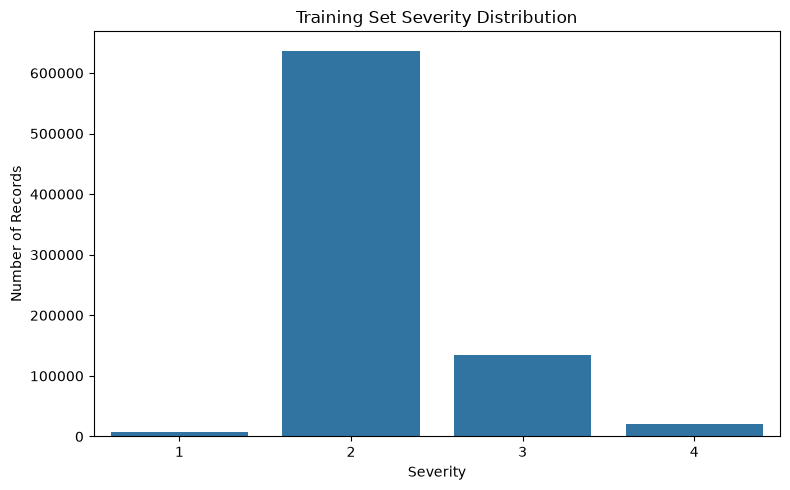

In [7]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=train_target_distribution.index.astype(str),
    y=train_target_distribution["Count"]
)

plt.title("Training Set Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## Validation Strategy

The original sampled dataset was split into training and testing sets using stratification to preserve the Severity class distribution.

For baseline model development, the test set is kept separate and is not used for model selection.

A stratified validation split is created from the training data. Stratification is used because the target variable is highly imbalanced and we want the validation set to maintain the class distribution of the training data.

The validation set is used to compare baseline models. The final test set will be reserved for final evaluation after model selection and optimization.

In [8]:
from sklearn.model_selection import train_test_split

X_train_model, X_valid, y_train_model, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_SEED
)

print("Model-training set:", X_train_model.shape)
print("Validation set:", X_valid.shape)

Model-training set: (639738, 138)
Validation set: (159935, 138)


In [9]:
validation_distribution = pd.DataFrame({
    "Training %": y_train_model.value_counts(normalize=True).sort_index() * 100,
    "Validation %": y_valid.value_counts(normalize=True).sort_index() * 100
})

validation_distribution

,Training %,Validation %
Severity,,
1,0.861603,0.861600
2,79.646043,79.646106
3,16.875033,16.874980
4,2.617321,2.617313


## Model Evaluation Metrics

A common evaluation function is defined so that all baseline models are assessed using the same metrics.

Macro-averaged metrics are particularly important because they give equal importance to all four severity classes despite the class imbalance.

In [ ]:
def evaluate_model(model_name, model, X_eval, y_eval, training_time):
    y_pred = model.predict(X_eval)

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_eval, y_pred
        ),
        "Macro Precision": precision_score(
            
            y_eval, y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_eval, y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_eval, y_pred,
            average="macro",
            zero_division=0
        ),
        "Weighted F1": f1_score(
            y_eval, y_pred,
            average="weighted",
            zero_division=0
        ),
        "Training Time (sec)": training_time
    }

    return results, y_pred

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [12]:
xgb_label_encoder = LabelEncoder()

y_train_model_xgb = xgb_label_encoder.fit_transform(y_train_model)
y_valid_xgb = xgb_label_encoder.transform(y_valid)

print("Original classes:", xgb_label_encoder.classes_)
print("Encoded classes:", np.unique(y_train_model_xgb))

Original classes: [1 2 3 4]
Encoded classes: [0 1 2 3]


## Baseline Machine Learning Models

Four classification algorithms are selected to provide different modelling approaches:

1. **Logistic Regression** — a linear classification baseline.
2. **Decision Tree** — a nonlinear tree-based model.
3. **Random Forest** — an ensemble of decision trees using bagging.
4. **XGBoost** — a gradient boosting ensemble method.

This selection allows the performance of a simple linear model, a single nonlinear tree, and two ensemble approaches to be compared systematically.

In [13]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_SEED
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=4,
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
}

print("Models prepared:")
for name in models:
    print("-", name)

Models prepared:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost


## Train Logistic Regression



In [14]:
print("Training Logistic Regression...")

start_time = time.time()

models["Logistic Regression"].fit(
    X_train_model,
    y_train_model
)

logistic_time = time.time() - start_time

logistic_results, logistic_pred = evaluate_model(
    "Logistic Regression",
    models["Logistic Regression"],
    X_valid,
    y_valid,
    logistic_time
)

print(f"Training time: {logistic_time:.2f} seconds")
print(f"Accuracy: {logistic_results['Accuracy']:.4f}")
print(f"Macro Precision: {logistic_results['Macro Precision']:.4f}")
print(f"Macro Recall: {logistic_results['Macro Recall']:.4f}")
print(f"Macro F1: {logistic_results['Macro F1']:.4f}")
print(f"Weighted F1: {logistic_results['Weighted F1']:.4f}")

Training Logistic Regression...
Training time: 30.45 seconds
Accuracy: 0.8384
Macro Precision: 0.6576
Macro Recall: 0.3696
Macro F1: 0.3916
Weighted F1: 0.8157


### Logistic Regression — Classification Report



In [15]:
print(
    classification_report(
        y_valid,
        logistic_pred,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           1     0.4706    0.0174    0.0336      1378
           2     0.8614    0.9520    0.9045    127382
           3     0.6707    0.4678    0.5512     26989
           4     0.6277    0.0411    0.0771      4186

    accuracy                         0.8384    159935
   macro avg     0.6576    0.3696    0.3916    159935
weighted avg     0.8197    0.8384    0.8157    159935



## Train Decision Tree



In [16]:
print("Training Decision Tree...")

start_time = time.time()

models["Decision Tree"].fit(
    X_train_model,
    y_train_model
)

decision_tree_time = time.time() - start_time

decision_tree_results, decision_tree_pred = evaluate_model(
    "Decision Tree",
    models["Decision Tree"],
    X_valid,
    y_valid,
    decision_tree_time
)

print(f"Training time: {decision_tree_time:.2f} seconds")
print(f"Accuracy: {decision_tree_results['Accuracy']:.4f}")
print(f"Macro Precision: {decision_tree_results['Macro Precision']:.4f}")
print(f"Macro Recall: {decision_tree_results['Macro Recall']:.4f}")
print(f"Macro F1: {decision_tree_results['Macro F1']:.4f}")
print(f"Weighted F1: {decision_tree_results['Weighted F1']:.4f}")

Training Decision Tree...
Training time: 26.29 seconds
Accuracy: 0.8680
Macro Precision: 0.6232
Macro Recall: 0.6311
Macro F1: 0.6270
Weighted F1: 0.8686


### Decision Tree — Classification Report



In [17]:
print(
    classification_report(
        y_valid,
        decision_tree_pred,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           1     0.5616    0.5755    0.5685      1378
           2     0.9237    0.9215    0.9226    127382
           3     0.7176    0.7167    0.7171     26989
           4     0.2897    0.3108    0.2999      4186

    accuracy                         0.8680    159935
   macro avg     0.6232    0.6311    0.6270    159935
weighted avg     0.8692    0.8680    0.8686    159935



## Train Random Forest



In [18]:
print("Training Random Forest...")

start_time = time.time()

models["Random Forest"].fit(
    X_train_model,
    y_train_model
)

random_forest_time = time.time() - start_time

random_forest_results, random_forest_pred = evaluate_model(
    "Random Forest",
    models["Random Forest"],
    X_valid,
    y_valid,
    random_forest_time
)

print(f"Training time: {random_forest_time:.2f} seconds")
print(f"Accuracy: {random_forest_results['Accuracy']:.4f}")
print(f"Macro Precision: {random_forest_results['Macro Precision']:.4f}")
print(f"Macro Recall: {random_forest_results['Macro Recall']:.4f}")
print(f"Macro F1: {random_forest_results['Macro F1']:.4f}")
print(f"Weighted F1: {random_forest_results['Weighted F1']:.4f}")

Training Random Forest...
Training time: 37.38 seconds
Accuracy: 0.8983
Macro Precision: 0.8144
Macro Recall: 0.5790
Macro F1: 0.6475
Weighted F1: 0.8900


### Random Forest — Classification Report


In [19]:
print(
    classification_report(
        y_valid,
        random_forest_pred,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           1     0.8602    0.4332    0.5763      1378
           2     0.9153    0.9657    0.9398    127382
           3     0.8156    0.7118    0.7601     26989
           4     0.6664    0.2052    0.3138      4186

    accuracy                         0.8983    159935
   macro avg     0.8144    0.5790    0.6475    159935
weighted avg     0.8915    0.8983    0.8900    159935



## Train XGBoost


In [20]:
print("Training XGBoost...")

start_time = time.time()

models["XGBoost"].fit(
    X_train_model,
    y_train_model_xgb
)

xgboost_time = time.time() - start_time

xgboost_pred_encoded = models["XGBoost"].predict(X_valid)

xgboost_pred = xgb_label_encoder.inverse_transform(
    xgboost_pred_encoded.astype(int)
)

xgboost_results, _ = evaluate_model(
    "XGBoost",
    models["XGBoost"],
    X_valid,
    y_valid_xgb,
    xgboost_time
)

# Recalculate metrics using the original Severity labels.
xgboost_results["Accuracy"] = accuracy_score(
    y_valid,
    xgboost_pred
)

xgboost_results["Macro Precision"] = precision_score(
    y_valid,
    xgboost_pred,
    average="macro",
    zero_division=0
)

xgboost_results["Macro Recall"] = recall_score(
    y_valid,
    xgboost_pred,
    average="macro",
    zero_division=0
)

xgboost_results["Macro F1"] = f1_score(
    y_valid,
    xgboost_pred,
    average="macro",
    zero_division=0
)

xgboost_results["Weighted F1"] = f1_score(
    y_valid,
    xgboost_pred,
    average="weighted",
    zero_division=0
)

print(f"Training time: {xgboost_time:.2f} seconds")
print(f"Accuracy: {xgboost_results['Accuracy']:.4f}")
print(f"Macro Precision: {xgboost_results['Macro Precision']:.4f}")
print(f"Macro Recall: {xgboost_results['Macro Recall']:.4f}")
print(f"Macro F1: {xgboost_results['Macro F1']:.4f}")
print(f"Weighted F1: {xgboost_results['Weighted F1']:.4f}")

Training XGBoost...
Training time: 19.40 seconds
Accuracy: 0.8888
Macro Precision: 0.7782
Macro Recall: 0.5921
Macro F1: 0.6483
Weighted F1: 0.8812


### XGBoost — Classification Report


In [21]:
print(
    classification_report(
        y_valid,
        xgboost_pred,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           1     0.7401    0.5022    0.5984      1378
           2     0.9127    0.9567    0.9342    127382
           3     0.7738    0.6924    0.7309     26989
           4     0.6863    0.2169    0.3296      4186

    accuracy                         0.8888    159935
   macro avg     0.7782    0.5921    0.6483    159935
weighted avg     0.8819    0.8888    0.8812    159935



## Systematic Baseline Model Comparison



In [22]:
results = [
    logistic_results,
    decision_tree_results,
    random_forest_results,
    xgboost_results
]

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (sec)
0,XGBoost,0.888849,0.778233,0.592062,0.648264,0.881168,19.395527
1,Random Forest,0.898340,0.814369,0.578973,0.647497,0.889964,37.380232
2,Decision Tree,0.867990,0.623158,0.631115,0.627022,0.868599,26.290437
3,Logistic Regression,0.838434,0.657601,0.369592,0.391589,0.815687,30.453329


### Store Validation Predictions


In [23]:
predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred,
    "XGBoost": xgboost_pred
}

print("Predictions stored for:")
for model_name in predictions:
    print("-", model_name)

Predictions stored for:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost


### Compare Evaluation Metrics


In [24]:
metrics_to_display = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1"
]

results_df[
    ["Model"] + metrics_to_display
]

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,XGBoost,0.888849,0.778233,0.592062,0.648264,0.881168
1,Random Forest,0.898340,0.814369,0.578973,0.647497,0.889964
2,Decision Tree,0.867990,0.623158,0.631115,0.627022,0.868599
3,Logistic Regression,0.838434,0.657601,0.369592,0.391589,0.815687


### Visual Comparison of Model Performance


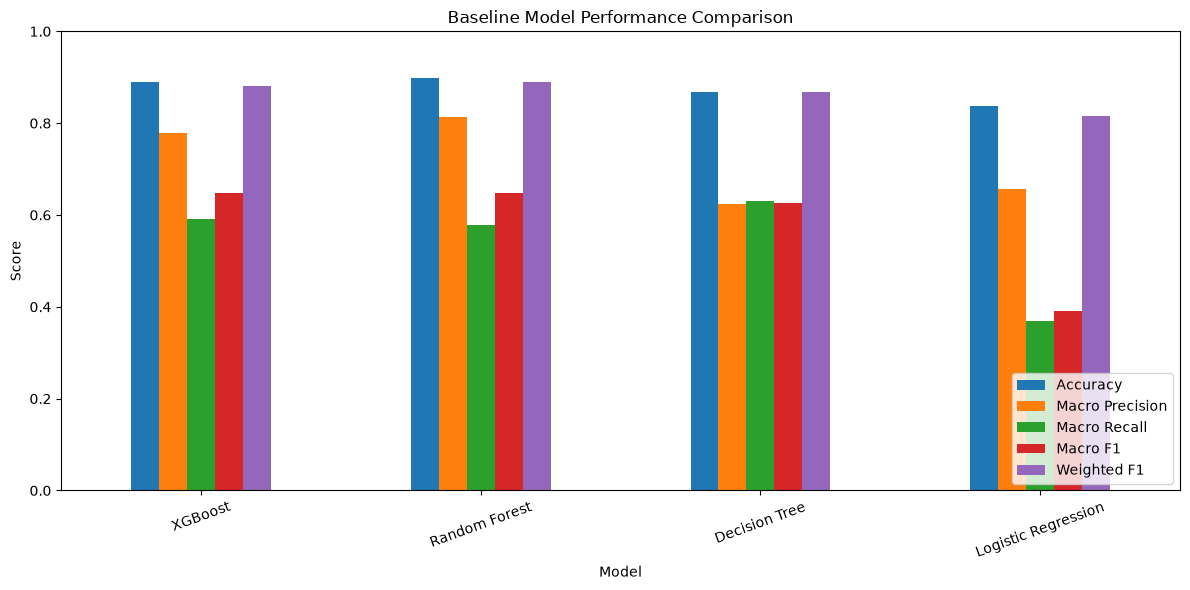

In [25]:
results_plot = results_df.set_index("Model")[
    metrics_to_display
]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Confusion Matrix Analysis


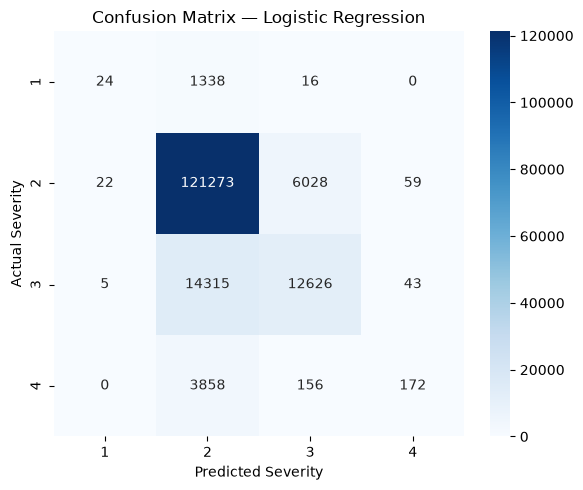

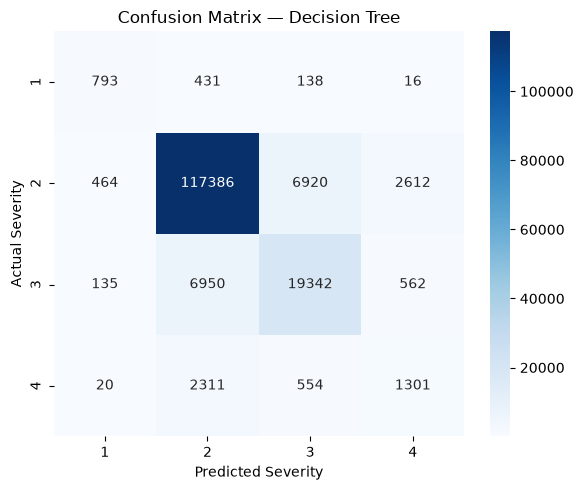

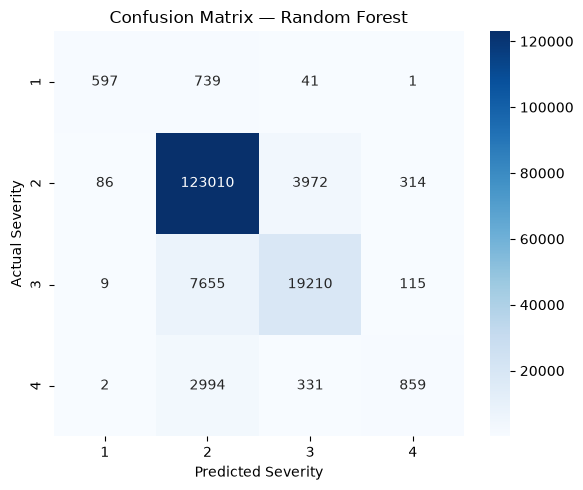

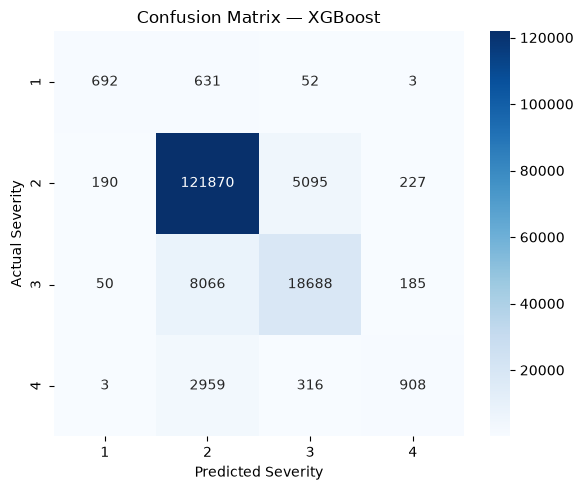

In [26]:
for model_name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_valid,
        y_pred,
        labels=[1, 2, 3, 4]
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[1, 2, 3, 4],
        yticklabels=[1, 2, 3, 4]
    )

    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted Severity")
    plt.ylabel("Actual Severity")
    plt.tight_layout()
    plt.show()

In [27]:
REPORT_DIR = "../outputs/reports"

os.makedirs(REPORT_DIR, exist_ok=True)

results_path = os.path.join(
    REPORT_DIR,
    "stage6_baseline_model_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print(f"Saved baseline results to: {results_path}")

Saved baseline results to: ../outputs/reports\stage6_baseline_model_results.csv
